In [8]:
import os
import cv2
import numpy as np
import pandas as pd
import pydicom
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
import shutil
import yaml

In [9]:
BASE_DIR = "/kaggle/input/vinbigdata-chest-xray-abnormalities-detection"
DICOM_DIR = os.path.join(BASE_DIR, "train")
CSV_PATH = os.path.join(BASE_DIR, "train.csv")
OUTPUT_DIR = "/kaggle/working/images"

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [10]:
base = "/kaggle/input/vinbigdata-chest-xray-abnormalities-detection"
print("Contents of base directory:")
print(os.listdir(base))

Contents of base directory:
['sample_submission.csv', 'train.csv', 'test', 'train']


In [11]:
df = pd.read_csv(CSV_PATH)

print("Shape:", df.shape)
df.head()

Shape: (67914, 8)


,image_id,class_name,class_id,rad_id,x_min,y_min,x_max,y_max
0,50a418190bc3fb1ef1633bf9678929b3,No finding,14,R11,NaN,NaN,NaN,NaN
1,21a10246a5ec7af151081d0cd6d65dc9,No finding,14,R7,NaN,NaN,NaN,NaN
2,9a5094b2563a1ef3ff50dc5c7ff71345,Cardiomegaly,3,R10,691.0,1375.0,1653.0,1831.0
3,051132a778e61a86eb147c7c6f564dfe,Aortic enlargement,0,R10,1264.0,743.0,1611.0,1019.0
4,063319de25ce7edb9b1c6b8881290140,No finding,14,R10,NaN,NaN,NaN,NaN


In [12]:

MAX_FILES = 1500 

os.makedirs(OUTPUT_DIR, exist_ok=True)

def preprocess_image(ds):
    image = ds.pixel_array

    # Ensure grayscale
    if len(image.shape) == 3:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Min-Max normalization
    image = image.astype(np.float32)
    image -= image.min()
    image /= (image.max() + 1e-8)
    image *= 255.0
    image = image.astype(np.uint8)

    # CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    image = clahe.apply(image)

    # Light denoising
    image = cv2.GaussianBlur(image, (3, 3), 0)

    # Resize
    image = cv2.resize(image, (640, 640))

    return image


dicom_files = []

for root, _, files in os.walk(DICOM_DIR):
    for f in files:
        if f.lower().endswith((".dcm", ".dicom")):
            dicom_files.append(os.path.join(root, f))

print(f"Found {len(dicom_files)} DICOM files")

converted = set(os.listdir(OUTPUT_DIR))

for dicom_path in tqdm(dicom_files[len(converted):len(converted)+MAX_FILES]):
    filename = os.path.basename(dicom_path).replace(".dicom", ".png")

    if filename in converted:
        continue  # skip already converted files

    try:
        ds = pydicom.dcmread(dicom_path)
        image = preprocess_image(ds)

        output_path = os.path.join(OUTPUT_DIR, filename)
        cv2.imwrite(output_path, image)

    except Exception as e:
        print(f"Failed: {dicom_path} | {e}")


print("DICOM → PNG conversion completed")

Found 15000 DICOM files


100%|██████████| 1500/1500 [27:27<00:00,  1.10s/it]

DICOM → PNG conversion completed


(np.float64(-0.5), np.float64(639.5), np.float64(639.5), np.float64(-0.5))

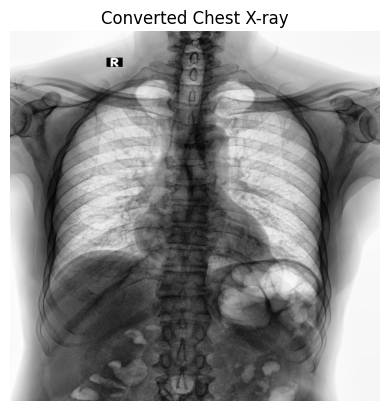

In [13]:
img_file = os.listdir("/kaggle/working/images")[0]
img = cv2.imread(f"/kaggle/working/images/{img_file}", cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap="gray")
plt.title("Converted Chest X-ray")
plt.axis("off")

In [14]:
# shows how many images have been converted
total_dicom = len(dicom_files)

converted_images = [
    f for f in os.listdir(OUTPUT_DIR)
    if f.lower().endswith(".png")
]

print("Total DICOM files:", total_dicom)
print("Converted PNG files:", len(converted_images))
print("Remaining:", total_dicom - len(converted_images))

Total DICOM files: 15000
Converted PNG files: 1500
Remaining: 13500


In [15]:
#size of each DICOM image.
ds = pydicom.dcmread(dicom_files[0])
print(ds.pixel_array.shape)

(3000, 3000)


In [16]:
print("Total rows:", df.shape[0])
print("Unique images:", df["image_id"].nunique())
print("\nUnique classes:")
print(df["class_name"].unique())

print("\nClass distribution:")
print(df["class_name"].value_counts())

Total rows: 67914
Unique images: 15000

Unique classes:
['No finding' 'Cardiomegaly' 'Aortic enlargement' 'Pleural thickening'
 'ILD' 'Nodule/Mass' 'Pulmonary fibrosis' 'Lung Opacity' 'Atelectasis'
 'Other lesion' 'Infiltration' 'Pleural effusion' 'Calcification'
 'Consolidation' 'Pneumothorax']

Class distribution:
class_name
No finding            31818
Aortic enlargement     7162
Cardiomegaly           5427
Pleural thickening     4842
Pulmonary fibrosis     4655
Nodule/Mass            2580
Lung Opacity           2483
Pleural effusion       2476
Other lesion           2203
Infiltration           1247
ILD                    1000
Calcification           960
Consolidation           556
Atelectasis             279
Pneumothorax            226
Name: count, dtype: int64


In [17]:
classes = sorted(df["class_name"].unique())
classes.remove("No finding")  # YOLO does not use this

class_to_id = {cls: idx for idx, cls in enumerate(classes)}

print(class_to_id)

{'Aortic enlargement': 0, 'Atelectasis': 1, 'Calcification': 2, 'Cardiomegaly': 3, 'Consolidation': 4, 'ILD': 5, 'Infiltration': 6, 'Lung Opacity': 7, 'Nodule/Mass': 8, 'Other lesion': 9, 'Pleural effusion': 10, 'Pleural thickening': 11, 'Pneumothorax': 12, 'Pulmonary fibrosis': 13}


In [18]:
IMG_SIZE = 640
ORIG_SIZE = 3000

scale = IMG_SIZE / ORIG_SIZE

LABELS_DIR = "/kaggle/working/labels"
os.makedirs(LABELS_DIR, exist_ok=True)

for image_id in df["image_id"].unique():
    rows = df[df["image_id"] == image_id]

    label_path = os.path.join(LABELS_DIR, image_id + ".txt")

    with open(label_path, "w") as f:
        for _, row in rows.iterrows():

            if row["class_name"] == "No finding":
                continue

            class_id = class_to_id[row["class_name"]]

            # Scale coordinates
            x_min = row["x_min"] * scale
            x_max = row["x_max"] * scale
            y_min = row["y_min"] * scale
            y_max = row["y_max"] * scale

 # YOLO normalized format
            x_center = ((x_min + x_max) / 2) / IMG_SIZE
            y_center = ((y_min + y_max) / 2) / IMG_SIZE
            width = (x_max - x_min) / IMG_SIZE
            height = (y_max - y_min) / IMG_SIZE

            f.write(f"{class_id} {x_center} {y_center} {width} {height}\n")


In [19]:
BASE_WORKING = "/kaggle/working"
DATASET_DIR = os.path.join(BASE_WORKING, "dataset")

IMAGES_SRC = OUTPUT_DIR
LABELS_SRC = LABELS_DIR

TRAIN_IMG = os.path.join(DATASET_DIR, "images/train")
VAL_IMG = os.path.join(DATASET_DIR, "images/val")
TRAIN_LBL = os.path.join(DATASET_DIR, "labels/train")
VAL_LBL = os.path.join(DATASET_DIR, "labels/val")

# Create folders
for path in [TRAIN_IMG, VAL_IMG, TRAIN_LBL, VAL_LBL]:
    os.makedirs(path, exist_ok=True)

# Get all image filenames
image_files = [f for f in os.listdir(IMAGES_SRC) if f.endswith(".png")]

# Shuffle and split
random.seed(42)
random.shuffle(image_files)

split_index = int(0.8 * len(image_files))
train_files = image_files[:split_index]
val_files = image_files[split_index:]

def move_files(file_list, img_dest, lbl_dest):
    for file in file_list:
        img_src = os.path.join(IMAGES_SRC, file)
        lbl_src = os.path.join(LABELS_SRC, file.replace(".png", ".txt"))

        shutil.copy(img_src, os.path.join(img_dest, file))
        shutil.copy(lbl_src, os.path.join(lbl_dest, file.replace(".png", ".txt")))

move_files(train_files, TRAIN_IMG, TRAIN_LBL)
move_files(val_files, VAL_IMG, VAL_LBL)

print("Train:", len(train_files))
print("Val:", len(val_files))

Train: 1200
Val: 300


In [20]:
dataset_yaml = {
    "path": DATASET_DIR,
    "train": "images/train",
    "val": "images/val",
    "nc": len(class_to_id),
    "names": list(class_to_id.keys())
}

with open(os.path.join(DATASET_DIR, "dataset.yaml"), "w") as f:
    yaml.dump(dataset_yaml, f)

print("dataset.yaml created")

dataset.yaml created


(np.float64(-0.5), np.float64(639.5), np.float64(639.5), np.float64(-0.5))

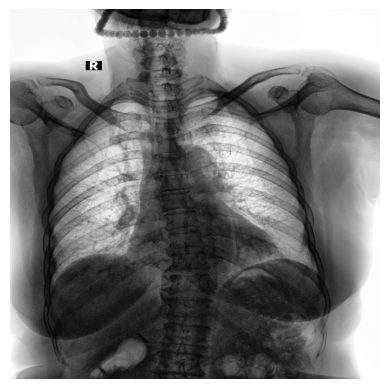

In [21]:
import random
import matplotlib.pyplot as plt

sample_img = random.choice(os.listdir(TRAIN_IMG))
img_path = os.path.join(TRAIN_IMG, sample_img)
label_path = os.path.join(TRAIN_LBL, sample_img.replace(".png", ".txt"))

img = cv2.imread(img_path)
h, w, _ = img.shape

with open(label_path, "r") as f:
    lines = f.readlines()

for line in lines:
    cls, x, y, bw, bh = map(float, line.strip().split())

    x_center = int(x * w)
    y_center = int(y * h)
    box_w = int(bw * w)
    box_h = int(bh * h)
    x1 = int(x_center - box_w / 2)
    y1 = int(y_center - box_h / 2)
    x2 = int(x_center + box_w / 2)
    y2 = int(y_center + box_h / 2)

    cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,0), 2)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")